In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

In [2]:
df = pd.read_csv(
    "Data/BTC_historical_INR.csv",
    parse_dates=["Date"],
    index_col="Date"
)

df = df.sort_index()

df = df.asfreq("D")

close = df["Close"].dropna()

In [3]:
split_ratio = 0.8
split_index = int(len(close) * split_ratio)

train = close.iloc[:split_index]
test  = close.iloc[split_index:]

In [4]:
history = list(train)
predictions = []

order = (1, 1, 1)   # simple & stable

for t in range(len(test)):
    model = ARIMA(history, order=order)
    model_fit = model.fit()
    yhat = model_fit.forecast()[0]
    predictions.append(yhat)
    history.append(test.iloc[t])

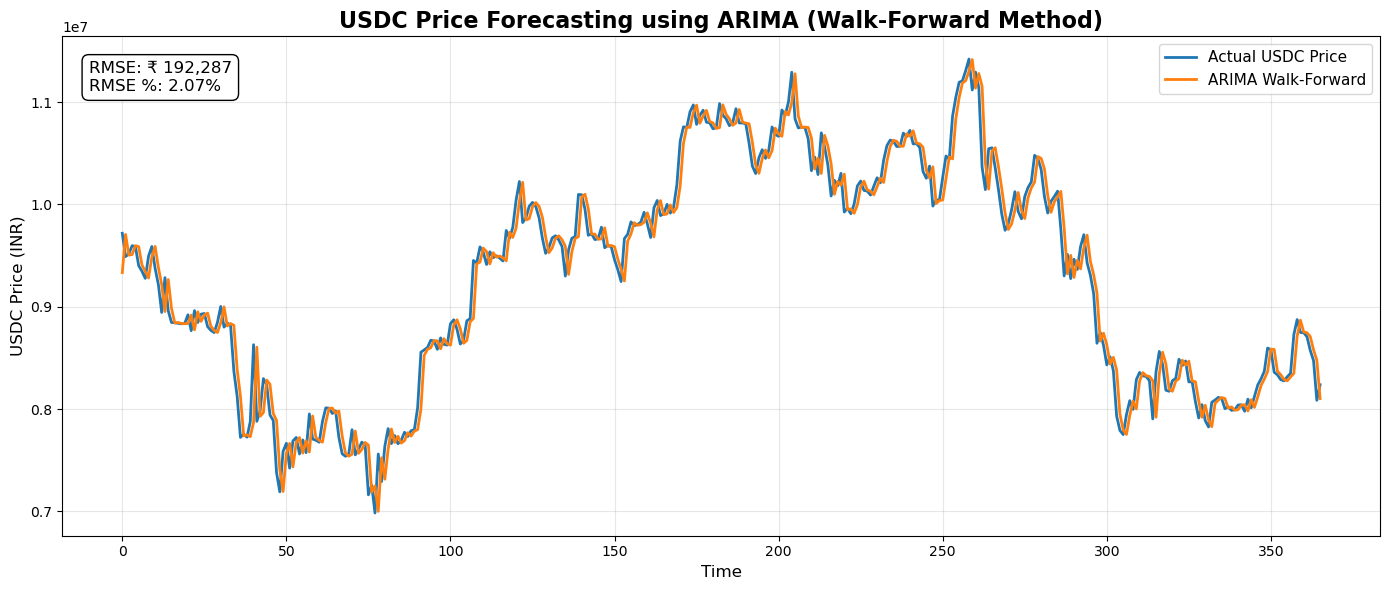

In [5]:
rmse = np.sqrt(mean_squared_error(test, predictions))
rmse_percent = (rmse / np.mean(test)) * 100

inr_rmse_on_fig = f"₹ {rmse:,.0f}"
percent_rmse_on_fig = f"{rmse_percent:.2f}%"

plt.figure(figsize=(14,6))

plt.plot(test.values, label="Actual USDC Price", linewidth=2)
plt.plot(predictions, label="ARIMA Walk-Forward", linewidth=2)

plt.title("USDC Price Forecasting using ARIMA (Walk-Forward Method)", fontsize=16, fontweight='bold')
plt.xlabel("Time", fontsize=12)
plt.ylabel("USDC Price (INR)", fontsize=12)

# 📦 METRICS BOX
metrics_text = f"RMSE: {inr_rmse_on_fig}\nRMSE %: {percent_rmse_on_fig}"

plt.text(
    0.02, 0.95, metrics_text,
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment='top',
    bbox=dict(boxstyle="round,pad=0.4", facecolor='white', edgecolor='black')
)

plt.legend(fontsize=11)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("USDC_ARIMA_WALK_FORWARD.png", dpi=300, bbox_inches='tight')
plt.show()

### Note : “Walk-forward ARIMA produces low one-step-ahead error because it is updated with real observations at each step. While effective for online prediction, it is not suitable for long-horizon forecasting comparison.”